### Modeling Strategy
In this notebook, we will evaluate the different models and thier results on the test data.
1. Model 1: BERT parameters are frozen and the final classification layers are trained.
2. Model 2: Unfreeze some of the layers and the output layers. Allow the model to update with a smaller learning rate.
3. Model 3: Unfreeze all the layers and let it learn slowly.

In [3]:
import torch
from torch import nn, optim
import pandas as pd
import numpy as np
from tqdm import tqdm
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.metrics import classification_report
from transformers import BertTokenizer, BertModel, AdamW
from matplotlib import pyplot as plt

ModuleNotFoundError: No module named 'torch'

### Modeling with BERT
Since we aleady went through data preprocessing and exploratory data analysis, we will directly conduct the modeling in this notebook.

In [3]:
filepath = '../../data/data-final-cleaned-llm.csv'
df = pd.read_csv(filepath)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14262 entries, 0 to 14261
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Source       14262 non-null  object
 1   Category     14262 non-null  object
 2   Headline     14261 non-null  object
 3   Description  14262 non-null  object
 4   Link         14262 non-null  object
 5   Date         14262 non-null  object
 6   Author       14261 non-null  object
 7   Target       14262 non-null  int64 
dtypes: int64(1), object(7)
memory usage: 891.5+ KB


#### Setting up the Dataset and Dataloader for training

In [4]:
# Let's define the dataset class now
# Make sure the __init_ class has access to all the data
# __getitem__ focusses on a single sample from the data defined in the __init__ class
# The returns of __getitem__ function should be a tensor as well.
# Otherwise collection of data in the batch throws an error


class NewsDataset(Dataset):
    def __init__(self, df, tokenizer):
        super().__init__()
        self.df = df
        self.text = (self.df['Headline'] + self.df['Description']).astype('str')  # pandas dataframe
        self.labels = self.df['Target']
        self.tokenizer = tokenizer
        
    def __len__(self):
        return self.df.shape[0]

    def __getitem__(self, idx):
        text = self.text.iloc[idx]
        label = self.labels.iloc[idx]
        inputs = tokenizer(text, padding='max_length', truncation=True, return_tensors="pt")
        input_id = inputs['input_ids'].flatten()
        attention_mask = inputs['attention_mask'].flatten()
        return input_id, attention_mask, torch.tensor(label, dtype=torch.int64)

In [5]:
# Train, Validation and Test splitting of the data
train_df, test_df = train_test_split(df, test_size=0.2, random_state=43, stratify=df['Target'])
val_df, test_df = train_test_split(test_df, test_size=0.5, random_state=43, stratify=test_df['Target'])
print(train_df.shape, val_df.shape, test_df.shape)

(11409, 8) (1426, 8) (1427, 8)


In [6]:
tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

## Getting the dataset
## Dataset class allow the retrieval of features and labels one sample at a time
train_dataset = NewsDataset(train_df, tokenizer)
val_dataset = NewsDataset(val_df, tokenizer)
test_dataset = NewsDataset(test_df, tokenizer)

#Getting the dataloader
# Dataloader API will shuffle the data before each epoch and returns a minibatch of features and labels mentioned by the label size
# Basically collect several samples and convert that into a minibatch
# Here each batch will have 64 integer ids, their attention mask and class labels
train_dataloader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_dataloader = DataLoader(val_dataset, batch_size=16, shuffle=True)
test_dataloader = DataLoader(test_dataset, batch_size=16, shuffle=True)

In [22]:
# Lets define the model class
class BertClassifier(nn.Module):
    def __init__(self, model_name, num_classes):
        super().__init__()
        self.bert = BertModel.from_pretrained(model_name) # The model will output would be [batch_size, sequence_length, hidden_states]
        # hidden_states = 768 for the base model
        self.dropout = nn.Dropout(0.1)
        self.fc = nn.Linear(self.bert.config.hidden_size, num_classes)

    def forward(self, input_ids, attention_mask):
        output = self.bert(input_ids=input_ids, attention_mask=attention_mask) # [batch_size, sequence_length, hidden_states]
        # Now we need to collect the hidden state of CLS (first) token
        # cls_hidden_state = output[:,0,:] # calling the first token
        # pooler output = tanh(dense(cls_hidden_state))
        pooler = output.pooler_output
        drop = self.dropout(pooler)
        logits = self.fc(drop)
        return logits

In [51]:
device = torch.device("mps") if torch.backends.mps.is_available() else "cpu"
print(f"Using {device}")

Using mps


## BERT Freezed + Linear classifier (on)
###  Model evaluation on validation and test data

In [60]:
# Calling the model here, load everything to device. Do not initialize in the cpu and then load it to the GPU.
model1 = BertClassifier("bert-base-uncased", 2).to(device)
# Load the saved model state dictionary containing all the learned parameters
model1.load_state_dict(torch.load("models/bert_base-freeze.pth", weights_only=True))

<All keys matched successfully>

#### Metrics on evaluation data

In [61]:
# Set the model to the evaluatio mode
y_out_list = []
y_true_list = []

model1.eval()
with torch.no_grad(): # no need to create the compuatational graph
    for input_ids, attention_masks, labels in tqdm(val_dataloader):
        
        input_ids = input_ids.to(device)
        attention_masks = attention_masks.to(device)
        labels = labels.to(device)

        # This will basically output the logits [batch, class]
        ypred = model1(input_ids=input_ids, attention_mask=attention_masks)

        ypred = torch.argmax(ypred, dim=1)
        y_out_list.append(ypred)
        y_true_list.append(labels)

        del input_ids, attention_masks, ypred

        # empty unused cache
        torch.mps.empty_cache()


100%|██████████████████████████████████████████████████████████████████████████████| 90/90 [00:52<00:00,  1.72it/s]


In [62]:
y_out_1_val = torch.cat(y_out_list, dim=0).detach().cpu().numpy() # detach the array from GPU and convert it to numpy array
y_true_1_val = torch.cat(y_true_list, dim=0).detach().cpu().numpy()

In [64]:
print("Validation data:")
print(f" Accuracy: {accuracy_score(y_true_1_val, y_out_1_val)} \n\
Precision : {precision_score(y_true_1_val, y_out_1_val)} \n\
Recall: {recall_score(y_true_1_val, y_out_1_val)} \n\
F1-score:{f1_score(y_true_1_val, y_out_1_val)}")

Validation data:
 Accuracy: 0.7124824684431977 
Precision : 0.7433460076045627 
Recall: 0.8481561822125814 
F1-score:0.7922998986828774


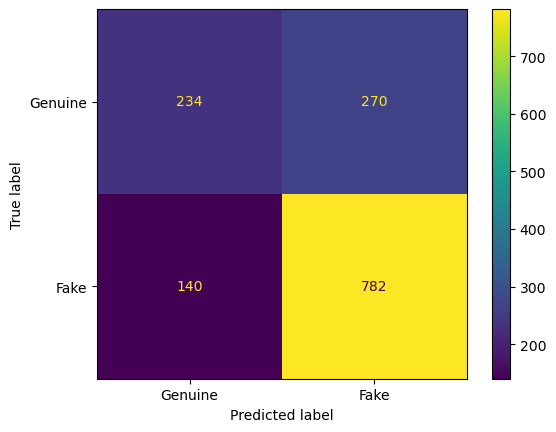

In [65]:
# Confusion matrix from the test data
ConfusionMatrixDisplay.from_predictions(y_true_1_val, y_out_1_val, display_labels = ['Genuine','Fake'])
plt.show()

#### Results on Test data

In [66]:
# Set the model to the evaluatio mode
y_out_list = []
y_true_list = []

model1.eval()
with torch.no_grad(): # no need to create the compuatational graph
    for input_ids, attention_masks, labels in tqdm(test_dataloader):
        
        input_ids = input_ids.to(device)
        attention_masks = attention_masks.to(device)
        labels = labels.to(device)

        # This will basically output the logits [batch, class]
        ypred = model1(input_ids=input_ids, attention_mask=attention_masks)

        ypred = torch.argmax(ypred, dim=1)
        y_out_list.append(ypred)
        y_true_list.append(labels)

        del input_ids, attention_masks, ypred

        # empty unused cache
        torch.mps.empty_cache()

100%|██████████████████████████████████████████████████████████████████████████████| 90/90 [00:52<00:00,  1.72it/s]


In [67]:
y_out_1_test = torch.cat(y_out_list, dim=0).detach().cpu().numpy() # detach the array from GPU and convert it to numpy array
y_true_1_test = torch.cat(y_true_list, dim=0).detach().cpu().numpy()

print("Test data:")
print(f" Accuracy: {accuracy_score(y_true_1_test, y_out_1_test)} \n\
Precision : {precision_score(y_true_1_test, y_out_1_test)} \n\
Recall: {recall_score(y_true_1_test, y_out_1_test)} \n\
F1-score:{f1_score(y_true_1_test, y_out_1_test)}")

Test data:
 Accuracy: 0.7337070777855641 
Precision : 0.7588179218303146 
Recall: 0.8624052004333694 
F1-score:0.8073022312373225


In [107]:
print(classification_report(y_true_1_test, y_out_1_test, target_names=['Genuine', 'Fake']))

              precision    recall  f1-score   support

     Genuine       0.66      0.50      0.57       504
        Fake       0.76      0.86      0.81       923

    accuracy                           0.73      1427
   macro avg       0.71      0.68      0.69      1427
weighted avg       0.73      0.73      0.72      1427



In [68]:
del model1

## Fine tuning: Unfreeze 2 top layers of BERT and train

In [81]:
# Calling the model here, load everything to device. Do not initialize in the cpu and then load it to the GPU.
model2 = BertClassifier("bert-base-uncased", 2).to(device)
# Load the saved model state dictionary containing all the learned parameters
model2.load_state_dict(torch.load("models/bert_base-top_tuning.pth", weights_only=True))

<All keys matched successfully>

In [70]:
# Set the model to the evaluatio mode
y_out_list = []
y_true_list = []

model2.eval()
with torch.no_grad(): # no need to create the compuatational graph
    for input_ids, attention_masks, labels in tqdm(val_dataloader):
        
        input_ids = input_ids.to(device)
        attention_masks = attention_masks.to(device)
        labels = labels.to(device)

        # This will basically output the logits [batch, class]
        ypred = model2(input_ids=input_ids, attention_mask=attention_masks)

        ypred = torch.argmax(ypred, dim=1)
        y_out_list.append(ypred)
        y_true_list.append(labels)

        del input_ids, attention_masks, ypred

        # empty unused cache
        torch.mps.empty_cache()

100%|██████████████████████████████████████████████████████████████████████████████| 90/90 [00:52<00:00,  1.72it/s]


In [71]:
y_out_2_val = torch.cat(y_out_list, dim=0).detach().cpu().numpy() # detach the array from GPU and convert it to numpy array
y_true_2_val = torch.cat(y_true_list, dim=0).detach().cpu().numpy()

print("Validation data:")
print(f" Accuracy: {accuracy_score(y_true_2_val, y_out_2_val)} \n\
Precision : {precision_score(y_true_2_val, y_out_2_val)} \n\
Recall: {recall_score(y_true_2_val, y_out_2_val)} \n\
F1-score:{f1_score(y_true_2_val, y_out_2_val)}")

Validation data:
 Accuracy: 0.8330995792426368 
Precision : 0.9441558441558442 
Recall: 0.7885032537960954 
F1-score:0.859338061465721


#### Results on test data

In [82]:
# Set the model to the evaluatio mode
y_out_list = []
y_true_list = []

model2.eval()
with torch.no_grad(): # no need to create the compuatational graph
    for input_ids, attention_masks, labels in tqdm(test_dataloader):
        
        input_ids = input_ids.to(device)
        attention_masks = attention_masks.to(device)
        labels = labels.to(device)

        # This will basically output the logits [batch, class]
        ypred = model2(input_ids=input_ids, attention_mask=attention_masks)

        ypred = torch.argmax(ypred, dim=1)
        y_out_list.append(ypred)
        y_true_list.append(labels)

        del input_ids, attention_masks, ypred

        # empty unused cache
        torch.mps.empty_cache()

100%|██████████████████████████████████████████████████████████████████████████████| 90/90 [00:53<00:00,  1.70it/s]


In [83]:
y_out_2_test = torch.cat(y_out_list, dim=0).detach().cpu().numpy() # detach the array from GPU and convert it to numpy array
y_true_2_test = torch.cat(y_true_list, dim=0).detach().cpu().numpy()

print("Test data:")
print(f" Accuracy: {accuracy_score(y_true_2_test, y_out_2_test)} \n\
Precision : {precision_score(y_true_2_test, y_out_2_test)} \n\
Recall: {recall_score(y_true_2_test, y_out_2_test)} \n\
F1-score:{f1_score(y_true_2_test, y_out_2_test)}")

Test data:
 Accuracy: 0.8521373510861948 
Precision : 0.9461152882205514 
Recall: 0.8179848320693391 
F1-score:0.8773968622893666


In [106]:
print(classification_report(y_true_2_test, y_out_2_test, target_names=['Genuine', 'Fake']))

              precision    recall  f1-score   support

     Genuine       0.73      0.91      0.81       504
        Fake       0.95      0.82      0.88       923

    accuracy                           0.85      1427
   macro avg       0.84      0.87      0.85      1427
weighted avg       0.87      0.85      0.85      1427



In [84]:
del model2

### BERT top 2 layer unfreezed and fine tuned using all data columns

In [85]:
# Calling the model here, load everything to device. Do not initialize in the cpu and then load it to the GPU.
model3 = BertClassifier("bert-base-uncased", 2).to(device)
# Load the saved model state dictionary containing all the learned parameters
model3.load_state_dict(torch.load("models/bert_base-top_tuning-full.pth", weights_only=True))

<All keys matched successfully>

#### Results on validation data

In [86]:
# Set the model to the evaluatio mode
y_out_list = []
y_true_list = []


model3.eval()
with torch.no_grad(): # no need to create the compuatational graph
    for input_ids, attention_masks, labels in tqdm(val_dataloader):
        
        input_ids = input_ids.to(device)
        attention_masks = attention_masks.to(device)
        labels = labels.to(device)

        # This will basically output the logits [batch, class]
        ypred = model3(input_ids=input_ids, attention_mask=attention_masks)

        ypred = torch.argmax(ypred, dim=1)
        y_out_list.append(ypred)
        y_true_list.append(labels)

        del input_ids, attention_masks, ypred

        # empty unused cache
        torch.mps.empty_cache()

100%|██████████████████████████████████████████████████████████████████████████████| 90/90 [00:58<00:00,  1.55it/s]


In [88]:
y_out_3_val = torch.cat(y_out_list, dim=0).detach().cpu().numpy() # detach the array from GPU and convert it to numpy array
y_true_3_val = torch.cat(y_true_list, dim=0).detach().cpu().numpy()

print("Validation data:")
print(f" Accuracy: {accuracy_score(y_true_3_val, y_out_3_val)} \n\
Precision : {precision_score(y_true_3_val, y_out_3_val)} \n\
Recall: {recall_score(y_true_3_val, y_out_3_val)} \n\
F1-score:{f1_score(y_true_3_val, y_out_3_val)}")

Validation data:
 Accuracy: 0.5785413744740533 
Precision : 0.8689655172413793 
Recall: 0.40997830802603036 
F1-score:0.5571112748710391


#### Results on test data

In [90]:
# Set the model to the evaluatio mode
y_out_list = []
y_true_list = []

model3.eval()
with torch.no_grad(): # no need to create the compuatational graph
    for input_ids, attention_masks, labels in tqdm(test_dataloader):
        
        input_ids = input_ids.to(device)
        attention_masks = attention_masks.to(device)
        labels = labels.to(device)

        # This will basically output the logits [batch, class]
        ypred = model3(input_ids=input_ids, attention_mask=attention_masks)

        ypred = torch.argmax(ypred, dim=1)
        y_out_list.append(ypred)
        y_true_list.append(labels)

        del input_ids, attention_masks, ypred

        # empty unused cache
        torch.mps.empty_cache()

100%|██████████████████████████████████████████████████████████████████████████████| 90/90 [00:58<00:00,  1.55it/s]


In [95]:
y_out_3_test = torch.cat(y_out_list, dim=0).detach().cpu().numpy() # detach the array from GPU and convert it to numpy array
y_true_3_test = torch.cat(y_true_list, dim=0).detach().cpu().numpy()

print("Test data:")
print(f"Accuracy: {accuracy_score(y_true_3_test, y_out_3_test)} \n\
Precision : {precision_score(y_true_3_test, y_out_3_test)} \n\
Recall: {recall_score(y_true_3_test, y_out_3_test)} \n\
F1-score:{f1_score(y_true_3_test, y_out_3_test)}")

Test data:
Accuracy: 0.606166783461808 
Precision : 0.8949671772428884 
Recall: 0.4431202600216685 
F1-score:0.5927536231884057


In [105]:
print(classification_report(y_true_3_test, y_out_3_test, target_names=['Genuine', 'Fake']))

              precision    recall  f1-score   support

     Genuine       0.47      0.90      0.62       504
        Fake       0.89      0.44      0.59       923

    accuracy                           0.61      1427
   macro avg       0.68      0.67      0.61      1427
weighted avg       0.74      0.61      0.60      1427



Eventhough this model uses all the features, that is leading to overfitting of the data even though the losser were smaller compared to the earlier models.

In [ ]:
del model3

### Unfreeze all the BERT layers:
Here we are experimenting which model version gives better results on the data without overfitting. Here we allow all the model parameters to learn slowly based on the training data.

#### Results on the validation data

In [108]:
# Calling the model here, load everything to device. Do not initialize in the cpu and then load it to the GPU.
model4 = BertClassifier("bert-base-uncased", 2).to(device)
# Load the saved model state dictionary containing all the learned parameters
model4.load_state_dict(torch.load("models/bert_base-all_tuning.pth", weights_only=True))

<All keys matched successfully>

In [109]:
# Set the model to the evaluatio mode
y_out_list = []
y_true_list = []

model4.eval()
with torch.no_grad(): # no need to create the compuatational graph
    for input_ids, attention_masks, labels in tqdm(val_dataloader):
        
        input_ids = input_ids.to(device)
        attention_masks = attention_masks.to(device)
        labels = labels.to(device)

        # This will basically output the logits [batch, class]
        ypred = model4(input_ids=input_ids, attention_mask=attention_masks)

        ypred = torch.argmax(ypred, dim=1)
        y_out_list.append(ypred)
        y_true_list.append(labels)

        del input_ids, attention_masks, ypred

        # empty unused cache
        torch.mps.empty_cache()

100%|██████████████████████████████████████████████████████████████████████████████| 90/90 [00:57<00:00,  1.55it/s]


In [110]:
y_out_4_val = torch.cat(y_out_list, dim=0).detach().cpu().numpy() # detach the array from GPU and convert it to numpy array
y_true_4_val = torch.cat(y_true_list, dim=0).detach().cpu().numpy()

print("Validation data:")
print(f" Accuracy: {accuracy_score(y_true_4_val, y_out_4_val)} \n\
Precision : {precision_score(y_true_4_val, y_out_4_val)} \n\
Recall: {recall_score(y_true_4_val, y_out_4_val)} \n\
F1-score:{f1_score(y_true_4_val, y_out_4_val)}")

Validation data:
 Accuracy: 0.6465638148667602 
Precision : 0.6465638148667602 
Recall: 1.0 
F1-score:0.7853492333901193


#### Results on test data

In [111]:
# Set the model to the evaluatio mode
y_out_list = []
y_true_list = []

model4.eval()
with torch.no_grad(): # no need to create the compuatational graph
    for input_ids, attention_masks, labels in tqdm(test_dataloader):
        
        input_ids = input_ids.to(device)
        attention_masks = attention_masks.to(device)
        labels = labels.to(device)

        # This will basically output the logits [batch, class]
        ypred = model4(input_ids=input_ids, attention_mask=attention_masks)

        ypred = torch.argmax(ypred, dim=1)
        y_out_list.append(ypred)
        y_true_list.append(labels)

        del input_ids, attention_masks, ypred

        # empty unused cache
        torch.mps.empty_cache()

100%|██████████████████████████████████████████████████████████████████████████████| 90/90 [00:58<00:00,  1.54it/s]


In [112]:
y_out_4_test = torch.cat(y_out_list, dim=0).detach().cpu().numpy() # detach the array from GPU and convert it to numpy array
y_true_4_test = torch.cat(y_true_list, dim=0).detach().cpu().numpy()

print("Test data:")
print(f"Accuracy: {accuracy_score(y_true_4_test, y_out_4_test)} \n\
Precision : {precision_score(y_true_4_test, y_out_4_test)} \n\
Recall: {recall_score(y_true_4_test, y_out_4_test)} \n\
F1-score:{f1_score(y_true_4_test, y_out_4_test)}")

Test data:
Accuracy: 0.6468114926419061 
Precision : 0.6468114926419061 
Recall: 1.0 
F1-score:0.7855319148936171


In [113]:
print(classification_report(y_true_4_test, y_out_4_test, target_names=['Genuine', 'Fake']))

              precision    recall  f1-score   support

     Genuine       0.00      0.00      0.00       504
        Fake       0.65      1.00      0.79       923

    accuracy                           0.65      1427
   macro avg       0.32      0.50      0.39      1427
weighted avg       0.42      0.65      0.51      1427



/Users/savin/opt/anaconda3/envs/ds-torch/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/savin/opt/anaconda3/envs/ds-torch/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/savin/opt/anaconda3/envs/ds-torch/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{m

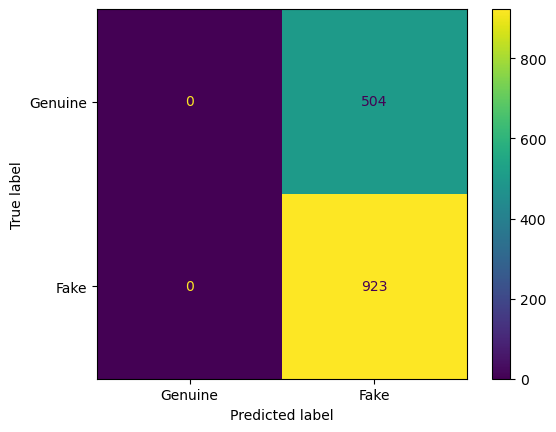

In [114]:
# Confusion matrix from the test data
ConfusionMatrixDisplay.from_predictions(y_true_4_test, y_out_4_test, display_labels = ['Genuine','Fake'])
plt.show()

### DistilBERT model (all layers unfreezed):
A miniature BERT model (with 6 encoder layers - 66 M parameters) trained through knowledge distillation technique. This basically uses the BERT (110 M parameters) as the parent model and distilbert as the student model where it is trained to reproduce the results of the parent model. This model is 40% smaller and 60% faster and can reproduce 97% of the BERT's language understanding capabilities. The loss function is a combination of the probability estimation made by the teacher and student, i.e, Sum(ti* log(si)).

In [115]:
from model_distilbert import DistilbertClassifier

# Calling the model here, load everything to device. Do not initialize in the cpu and then load it to the GPU.
model5 = DistilbertClassifier("distilbert-base-uncased", 2).to(device)
# Load the saved model state dictionary containing all the learned parameters
model5.load_state_dict(torch.load("models/distilbert_base-all_tuning.pth", weights_only=True))

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


<All keys matched successfully>

### Results on Validation data

In [116]:
# Set the model to the evaluatio mode
y_out_list = []
y_true_list = []

model5.eval()
with torch.no_grad(): # no need to create the compuatational graph
    for input_ids, attention_masks, labels in tqdm(val_dataloader):
        
        input_ids = input_ids.to(device)
        attention_masks = attention_masks.to(device)
        labels = labels.to(device)

        # This will basically output the logits [batch, class]
        ypred = model5(input_ids=input_ids, attention_mask=attention_masks)

        ypred = torch.argmax(ypred, dim=1)
        y_out_list.append(ypred)
        y_true_list.append(labels)

        del input_ids, attention_masks, ypred

        # empty unused cache
        torch.mps.empty_cache()

100%|██████████████████████████████████████████████████████████████████████████████| 90/90 [00:37<00:00,  2.37it/s]


In [117]:
y_out_5_val = torch.cat(y_out_list, dim=0).detach().cpu().numpy() # detach the array from GPU and convert it to numpy array
y_true_5_val = torch.cat(y_true_list, dim=0).detach().cpu().numpy()

print("Validation data:")
print(f" Accuracy: {accuracy_score(y_true_5_val, y_out_5_val)} \n\
Precision : {precision_score(y_true_5_val, y_out_5_val)} \n\
Recall: {recall_score(y_true_5_val, y_out_5_val)} \n\
F1-score:{f1_score(y_true_5_val, y_out_5_val)}")

Validation data:
 Accuracy: 0.8548387096774194 
Precision : 0.9104477611940298 
Recall: 0.8600867678958786 
F1-score:0.8845510317902956


### Results on Test data

In [118]:
# Set the model to the evaluatio mode
y_out_list = []
y_true_list = []

model5.eval()
with torch.no_grad(): # no need to create the compuatational graph
    for input_ids, attention_masks, labels in tqdm(test_dataloader):
        
        input_ids = input_ids.to(device)
        attention_masks = attention_masks.to(device)
        labels = labels.to(device)

        # This will basically output the logits [batch, class]
        ypred = model5(input_ids=input_ids, attention_mask=attention_masks)

        ypred = torch.argmax(ypred, dim=1)
        y_out_list.append(ypred)
        y_true_list.append(labels)

        del input_ids, attention_masks, ypred

        # empty unused cache
        torch.mps.empty_cache()

100%|██████████████████████████████████████████████████████████████████████████████| 90/90 [00:37<00:00,  2.41it/s]


In [119]:
y_out_5_test = torch.cat(y_out_list, dim=0).detach().cpu().numpy() # detach the array from GPU and convert it to numpy array
y_true_5_test = torch.cat(y_true_list, dim=0).detach().cpu().numpy()

print("Test data:")
print(f" Accuracy: {accuracy_score(y_true_5_test, y_out_5_test)} \n\
Precision : {precision_score(y_true_5_test, y_out_5_test)} \n\
Recall: {recall_score(y_true_5_test, y_out_5_test)} \n\
F1-score:{f1_score(y_true_5_test, y_out_5_test)}")

Test data:
 Accuracy: 0.8745620182200421 
Precision : 0.9227272727272727 
Recall: 0.8797399783315276 
F1-score:0.9007210205213533


In [121]:
print(classification_report(y_true_5_test, y_out_5_test, target_names=['Genuine', 'Fake']))

              precision    recall  f1-score   support

     Genuine       0.80      0.87      0.83       504
        Fake       0.92      0.88      0.90       923

    accuracy                           0.87      1427
   macro avg       0.86      0.87      0.87      1427
weighted avg       0.88      0.87      0.88      1427



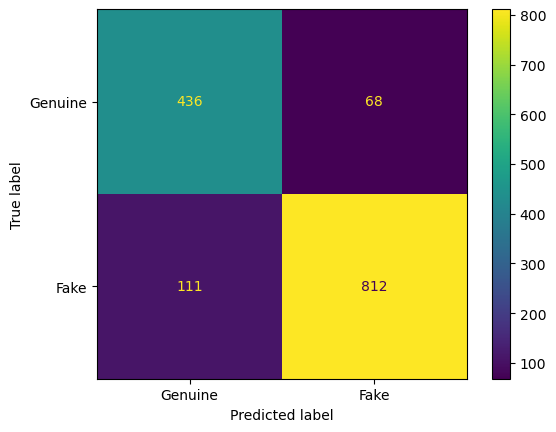

In [120]:
# Confusion matrix from the test data
ConfusionMatrixDisplay.from_predictions(y_true_5_test, y_out_5_test, display_labels = ['Genuine','Fake'])
plt.show()

### Quantization of the DistillBert Model
It's a good idea to quantize the models before deployment. Basically the idea is to change precision of the weights and the activation functions from doube precision to single precision (float 32 to float16 or int8). This will reduce the size, reduce the inference speed and reduce the memory consumption. There are 2 ways to do this: 
1. Static quantization: Reduce the precision of both weights and outputs of the activation layers before deployment.
2. Dynamic quantization: quantize the weights, but the outputs of activations are quantized on the fly during inference. Quantization on activation functions are applied only when the model is served.

Static is equivalent to open an image, compress and save it for faster loading. Dynamic is equivalent to compress the image everytime you open an image. Dynamic quantization is a good quick choice with minimal effort because static quantization requires recalibration of the data, model architecture changes and further training of the models. Plus dyanamic quantization gives better results on transformer models.

In [8]:
from model_distilbert import DistilbertClassifier

# Calling the model here
dist_full = DistilbertClassifier("distilbert-base-uncased", 2)
# Load the saved model state dictionary containing all the learned parameters
dist_full.load_state_dict(torch.load("models/distilbert_base-all_tuning.pth", weights_only=True, map_location="cpu"))

# Set the model to inference mode. So that quantization happens in the inference mode.
# The drop out regularizations are turned off in the inference mode. Also the batch normalization will use the running statistics instead of 
# updating them. Usually in BN, the mean and variance of each batch is calculated. During inference of a single sample, the running average
# of the mean and variance collected during training is used. Therefore it is important to set the model mode to eval before quantization.
dist_full.eval()

# quantization step
dist_quant = torch.quantization.quantize_dynamic(
    dist_full,
    {torch.nn.Linear},  # Only quantize linear layers, attention layers are not supported for quantization yet.
    dtype=torch.qint8   # 8-bit integers
)

torch.save(dist_quant.state_dict(), "models/distilbert_quantized.pth")

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


### Inference using quantized model
1. Define the model architecture
2. Apply quantization
3. Load the quantized weights for inference

In [6]:
from model_distilbert import DistilbertClassifier

# device
device = torch.device('cpu')
# Calling the model here
dist_model = DistilbertClassifier("distilbert-base-uncased", 2).to(device)

# quantization step
dist_quant = torch.quantization.quantize_dynamic(
    dist_model,
    {torch.nn.Linear},  # Only quantize linear layers, attention layers are not supported for quantization yet.
    dtype=torch.qint8   # 8-bit integers
)

# load weights into the defined model
dist_quant.load_state_dict(torch.load("models/distilbert_quantized.pth"))
dist_quant.eval()

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/Users/savin/opt/anaconda3/envs/ds-torch/lib/python3.9/site-packages/torch/_utils.py:383: UserWarning: TypedStorage is deprecated. It will be removed in the future and UntypedStorage will be the only storage class. This should only matter to you if you are using storages directly.  To access UntypedStorage directly, use tensor.untyped_storage() instead of tensor.storage()
  device=storage.device,


DistilbertClassifier(
  (distilbert): DistilBertForSequenceClassification(
    (distilbert): DistilBertModel(
      (embeddings): Embeddings(
        (word_embeddings): Embedding(30522, 768, padding_idx=0)
        (position_embeddings): Embedding(512, 768)
        (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (transformer): Transformer(
        (layer): ModuleList(
          (0-5): 6 x TransformerBlock(
            (attention): MultiHeadSelfAttention(
              (dropout): Dropout(p=0.1, inplace=False)
              (q_lin): DynamicQuantizedLinear(in_features=768, out_features=768, dtype=torch.qint8, qscheme=torch.per_tensor_affine)
              (k_lin): DynamicQuantizedLinear(in_features=768, out_features=768, dtype=torch.qint8, qscheme=torch.per_tensor_affine)
              (v_lin): DynamicQuantizedLinear(in_features=768, out_features=768, dtype=torch.qint8, qscheme=torch.per_tensor_affine)
      

## Inference of the Distilbert model on the CPU for deployment

In [ ]:
# Testing the results of the quantized model 
# Set the model to the evaluatio mode
dist_quant.eval()


y_out_list = []
y_true_list = []

with torch.no_grad(): # no need to create the compuatational graph
    for input_ids, attention_masks, labels in tqdm(test_dataloader):
        
        input_ids = input_ids.to(device)
        attention_masks = attention_masks.to(device)
        labels = labels.to(device)

        # This will basically output the logits [batch, class]
        ypred = dist_quant(input_ids=input_ids, attention_mask=attention_masks)

        ypred = torch.argmax(ypred, dim=1)
        y_out_list.append(ypred)
        y_true_list.append(labels)

        del input_ids, attention_masks, ypred

  0%|                                                                                               | 0/90 [00:00<?, ?it/s]

### Conclusion
Clearly unfreezing all the transformer layers did not do a good job in the classfication. The Model with few top layers unfreezed is giving the best results in this case.

DistilBERT model with all layers unfreezed during finetuning has outperformed the performance metrics from the large BERT model.